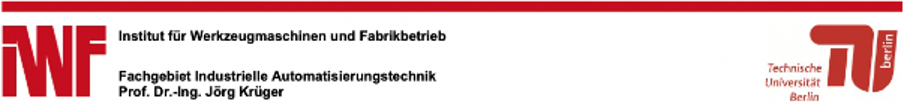



# Bildvorverarbeitung - Workflow

## 0.  Organisatorisches
## 1.	Videos zu Image per Frames
## 2.	Data Clean
## 3.	Datensatz
## 4.  Resultat



——————————————————————————————————————————————————————————————————————————————————————————————————————————————————————

### 0. Organisatorishes

Für die Verständlichkeit des Projekts und die Lesbarkeit der Programmierung wird eine Arbeitsanweisung erstellt. 
Installation: Sie benötigen die Installation von OpenCV 3.2.; Programmierungsprache(OpenCV-Python); IDE(Anaconda); 

Ziel von "Video zu Bild": 
> -Zusammenhängendem Bilde; -Durch einzelnen Frame extrahieren; -Eigentlich Frame überprüfen

Ziel von "Data Clean": 
> -Automatisiert; - Überlichtet; -Unterlichtet; - und Verdeckte Bild

### 1. Videos zu Image per Frames

Die Verwendung von OpenCV nimmt ein avi- oder mp4-Video und erzeugt eine Reihe von Bildern.

Schwerpunkt des Video-zu-Bildes:
> * Wir nutzen OpenCV um aus den Videos die einzelnen Frames zu extrahieren
> * Hier sollte überprüft werden, ob die Videos tatsächlich über weniger als 30 FPS verfügen oder ob die Extraktion mit OpenCV **weniger Frames liefert als eigentlich vorhanden sind**
> * Prinzipiell kann nicht ausgeschlossen werden, dass die Videos weniger FPS haben

Eingabe des Videos:

In [28]:
import cv2
import glob
import numpy as np
import os
os.chdir("/Users/xuhao/Library/CloudStorage/OneDrive-个人/A_MasterStudium/D_22WS_Proj_Automatisierung oder Robotik/Daten")
file_name_pattern = f"{os.getcwd()}/Sample*/**/*.avi"
video_files = glob.glob(file_name_pattern, recursive=True); #len(video_files)

**Video zu Bild**- Funktion erstellen, die Frames aus Videodateien wie mp4 und avi als Standbilddateien mit OpenCV in Python erfassen und speichern.

In [105]:
def save_all_frames(video_path, dir_path, basename, ext='jpg'):
    """This function also removes the duplicate frames.
    
    From: https://note.nkmk.me/en/python-opencv-video-to-still-image/
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return

    os.makedirs(dir_path, exist_ok=True)
    base_path = os.path.join(dir_path, basename)

    digit = len(str(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))))

    n = 0

    while True:
        ret, frame = cap.read()
        if ret:
            cv2.imwrite('{}_{}.{}'.format(base_path, str(n).zfill(digit), ext), frame)
            n += 1
        else:
            return

Laufen die Funktion. Hier wartet vielleicht von 5 bin 10 min.

In [ ]:
 for video_file in video_files:
    head, sep, tail = video_file.partition("Sample")
    frame_base_name = sep + tail
    frame_base_name = frame_base_name.rstrip(".avi").replace("/", "_")
    save_all_frames(video_file, './extracted_frames_no_duplicates', frame_base_name)

Check die eigentliche Framesrate des Videos:


In [34]:
def get_duration_from_cv2(filename):
    cap = cv2.VideoCapture(filename)
    if cap. isOpened():
        rate = cap.get(5)
        frame_num=cap.get(7)
        duration = frame_num/rate
        return duration
    return -1

# Example-Videos: '220615-152743-STtoST_3_6_10.avi'
os.chdir("/Users/xuhao/Library/CloudStorage/OneDrive-个人/A_MasterStudium/D_22WS_Proj_Automatisierung oder Robotik/Daten/extracted_frames_no_duplicates")
file_name_pattern = f"{os.getcwd()}/Sample1_Video_220615-152743-STtoST_3_6_10_*.jpg"
video_files = glob.glob(file_name_pattern, recursive=True); #len(video_files)
num_png = len(video_files)
print("Eigentlich frames : {0}".format(num_png))
seconds=get_duration_from_cv2('220615-152743-STtoST_3_6_10.avi')
# Calculate frames per second
fps  = num_png / seconds
print("Eigentlich framerate : {0}".format(fps))

Eigentlich frames : 1459
Eigentlich framerate : 20.73436957045945


### 2. Data Clean
#### 01. Konzept- Phase 1

In [19]:
import cv2
import os
import matplotlib.pyplot as plt
from PIL import Image,ImageChops
import random
from typing import List
import numpy as np
import glob
from tqdm import tqdm


def is_greyscale(im):
    """
    Check if image is monochrome (1 channel or 3 identical channels)

    From Stackoverflow: https://stackoverflow.com/questions/23660929/how-to-check-whether-a-jpeg-image-is-color-or-gray-scale-using-only-python-stdli
    """
    if im.mode not in ("L", "RGB"):
        raise ValueError("Unsuported image mode")

    if im.mode == "RGB":
        rgb = im.split()
        if ImageChops.difference(rgb[0],rgb[1]).getextrema()[1]!=0: 
            return False
        if ImageChops.difference(rgb[0],rgb[2]).getextrema()[1]!=0: 
            return False
    return True

In [20]:
example_images_path = "Sample1_Video_220615-152743-STtoST_3_6_10"

In [21]:
example_images_num_clean = [1, 150, 158, 165]
example_images_num_overexposed = [84, 86, 92]
# example_images_num_underexposed = [171, 187]
example_images_num_underexposed = [95, 164]

In [24]:
im = Image.open(f"{example_images_path}_{str(random.choice(example_images_num_clean)).zfill(4)}.jpg")

In [25]:
is_greyscale(im)

False

### Images appear to not be exactly greyscale

In [11]:
def show_histograms(path: str, image_nums: List[int]):
    """
    From: https://stackoverflow.com/questions/22159160/python-calculate-histogram-of-image
    """
    fig, axes = plt.subplots(1,len(image_nums))
    fig.set_size_inches(15,5)
    for image_num, ax in zip(image_nums, axes):
        image_path = f"{path}_{str(image_num).zfill(4)}.jpg"
        im = cv2.imread(image_path)
        # calculate mean value from RGB channels and flatten to 1D array
        vals = im.mean(axis=2).flatten()
        # plot histogram with 255 bins
        b, bins, patches = ax.hist(vals, 255)
        ax.set_xlim([0,255])

    plt.show()

### Let's look at the histogram of 'clean' images

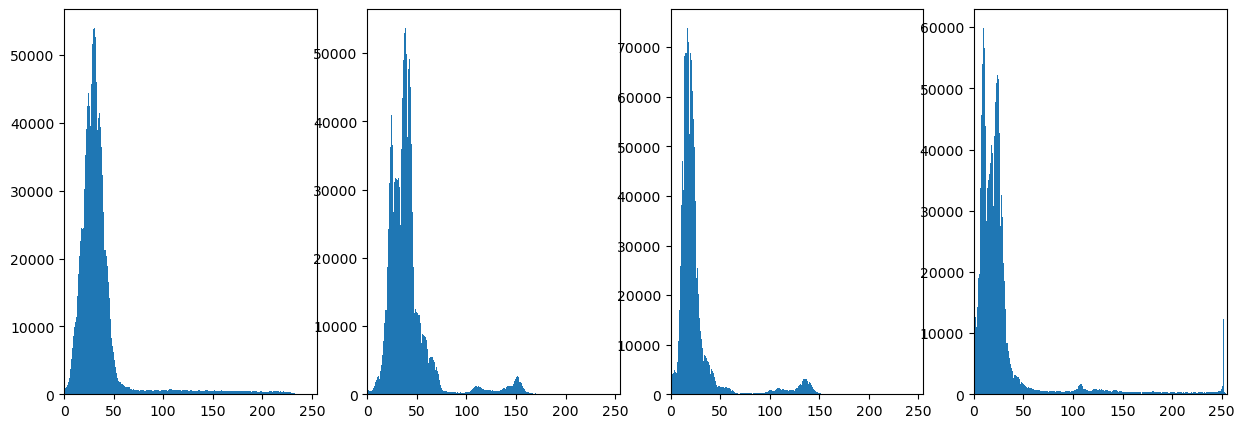

In [56]:
show_histograms(example_images_path, example_images_num_clean)

### Let's look at the histogram of overexposed images

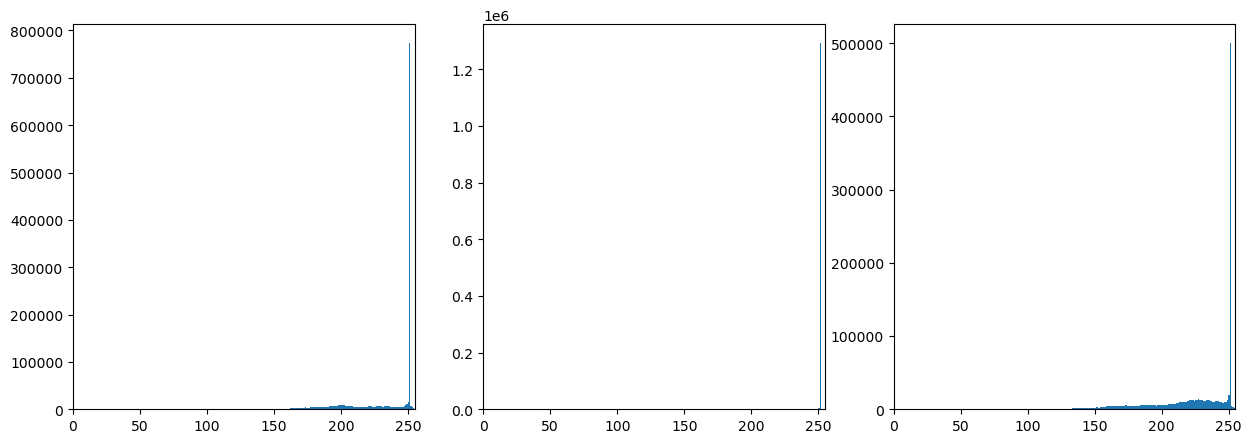

In [59]:
show_histograms(example_images_path, example_images_num_overexposed)

### Let's look at the histogram of underexposed images

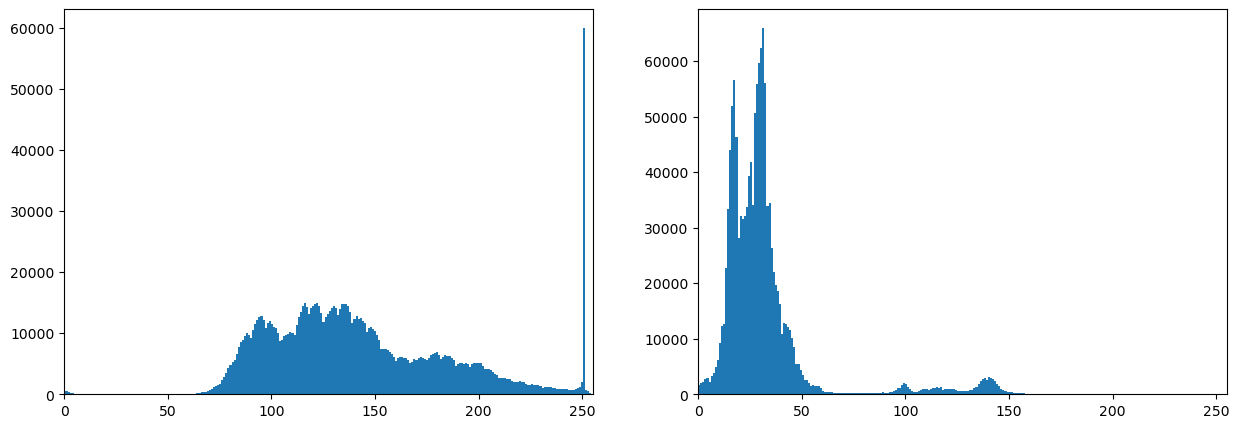

In [26]:
show_histograms(example_images_path, example_images_num_underexposed)

In [30]:
def is_overexposed(image_path: str, bins: int = 5):
    """
    We take a look at the histogram of the flattened picture (which is converted to greyscale first by taking the mean across the three color channels).
    Only if the last bin contains the largest number of pixels, we define the image to be overexposed.
    """
    im = cv2.imread(image_path)
    vals = im.mean(axis=2)
    return np.argmax(np.histogram(vals, bins=bins)[0]) == bins - 1

In [32]:
def is_underexposed(image_path: str, bins: int = 5):
    """
    We do not classfiy any images as underexposed as of now.
    """
    return False

In [36]:
for image_num in example_images_num_overexposed:
    image_path = f"{example_images_path}_{str(image_num).zfill(4)}.jpg"
    print(is_overexposed(image_path))

True
True
True


In [35]:
removed_counter = 0

frames_dir = "./extracted_frames_no_duplicates/"
removed_frames_dir = "./removed_frames/"

for frame_name in tqdm(glob.iglob(f"{frames_dir}*.jpg")):
    if is_overexposed(frame_name) or is_underexposed(frame_name):
        os.rename(frame_name, f"{removed_frames_dir}{frame_name.lstrip(frames_dir)}")
        removed_counter += 1

# print(f"Number of frames that have been removed from the data: {removed_counter}")

0it [00:00, ?it/s]


### 02. Konzept- Phase 2
Die Hauptquelle der aktuellen Analyse ist das Histogramm des Bildes.Dann werden weitere Informationen basierend auf dem Histogramm erweitert. Wie Beispiel: Mittelwert, Varianz, Entropie.

> Varianz:  Ein Streuungsmaß, welches die Verteilung von Werten um den Mittelwert kennzeichnet.

> Entropie: Eine Zunahme der Entropie bedeutet eine Zunahme der Unordnung im System.

**Example:**
Hier haben wir zehn Bilder für jede Kategorie ausgewählt. Dann werden die Daten tabelliert.



<div style="display:flex">
    InOrdnung:
     <div style="flex:1;padding-right:10px;">
          <img src="In Ordnung.png" width="1200" height="500"/>
     </div>
   Unterlichtet:
     <div style="flex:1;padding-left:10px;">
          <img src="Unterlichtet.png" height="400"/>
     </div>
</div>


<div style="display:flex">
     Überlichtet:
     <div style="flex:1;padding-left:10px;">
          <img src="Ueberlichtet.png" height="500"/>
     </div>
    Schweissvolke(verdeckte):
     <div style="flex:1;padding-left:10px;">
          <img src="Schweissvolke(verdeckte).png" height="400"/>
     </div>
</div>



### 03. Klassifizierung:
Hier werden 5 Klassen definieren.

Klassen | Status  | Beschreibung 
---| ---| ---|
1.Mit Lichtbogen  |Beibehalten| Mittelgrauwert großer als 50 aber kleiner als 100.
2.Ohne Lichtbogen |Beibehalten| Mittelgrauwert kleiner als 50. Und Varianz ungefähr 500-1000.
3.Überlichtete    |Löschen    | Mittelgrauwert großer als 150, Varianz je nach Intensität der Überlichtung.
4.Unterlichtete   |Löschen    | Mittelgrauwert ungefähr 50, besondere Varianz sehr kleiner(im Verglech zu "Ohne Lichtbogen")
5.Verdeckte Bilder|Löschen    | Mittelgrauwert zwischen 100 bis 200, dass muss genauer sein

In [38]:
# Example:
img = cv2.imread('Sample1_Video_220615-152743-STtoST_3_6_10_0096.jpg')
grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# img= is_grey('Sample1_Video_220615-152743-STtoST_3_6_10_0081.jpg')

In [39]:
def is_underexposed(grey):
    
    mean = np.mean(grey)
    varianz = np.var(grey)
    
    if mean <= 50:
        if varianz > 300:
            return False
        else:
            return True
    return False

In [40]:
is_underexposed(grey)

False

In [41]:
def is_gaswolke(grey):
    
    mean = np.mean(grey)
    varianz = np.var(grey)
    
    if mean >= 100:
        if mean < 150:
            return False
        else:
            return True
    return False

In [42]:
is_gaswolke(grey)

False

#### 3.Datensatz


#### 4. Resultat



Archiv:
> Workflow(Arbeitseinleitung): HTML und Notebook in Github.
> Datensatz: sieht https://tubcloud.tu-berlin.de/s/m2YseaFsLzxteoY?path=%2F08%20Bilder%20Dokument
> Diagrammfluss
